In [24]:
import pandas as pd # bring in the pandas library to read in data from a csv file
import numpy as np # bring in the numpy library to perform calculations on the data frame
df = pd.read_csv("CrashDataSet.csv") # reads the CSV file from the project folder
df.head() #shows the first 5 rows of the data frame



C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\1510198955.py:3: DtypeWarning: Columns (0: Speed Limit, 1: National Remoteness Areas, 2: SA4 Name 2021, 3: National LGA Name 2021, 4: National Road Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CrashDataSet.csv") # reads the CSV file from the project folder


,Crash ID,State,Month,Year,Dayweek,Time,Crash Type,Bus Involvement,Heavy Rigid Truck Involvement,Articulated Truck Involvement,...,National Remoteness Areas,SA4 Name 2021,National LGA Name 2021,National Road Type,Christmas Period,Easter Period,Age Group,Day of week,Time of day,Unnamed: 23
0,20237008,NT,10,2023,Friday,NaN,Single,No,No,No,...,NaN,NaN,NaN,NaN,No,No,17_to_25,Weekend,Night,NaN
1,20234009,SA,10,2023,Saturday,03:00,Single,No,No,No,...,Outer Regional Australia,Barossa - Yorke - Mid North,Yorke Peninsula,Local Road,No,No,17_to_25,Weekend,Night,NaN
2,20233087,Qld,10,2023,Saturday,03:00,Single,No,No,No,...,Inner Regional Australia,Wide Bay,Gympie,Collector Road,No,No,17_to_25,Weekend,Night,NaN
3,20233149,Qld,10,2023,Sunday,03:00,Single,No,No,No,...,Inner Regional Australia,Wide Bay,Bundaberg,Local Road,No,No,26_to_39,Weekend,Night,NaN
4,20233190,Qld,10,2023,Sunday,03:00,Multiple,No,No,No,...,Outer Regional Australia,Mackay - Isaac - Whitsunday,Mackay,Sub-arterial Road,No,No,26_to_39,Weekend,Night,NaN


In [25]:

print("Records:", df.shape[0]) # put print cause otherwise it will not show the output in the notebook
print("Features:", df.shape[1])

print(df.dtypes)

Records: 55360
Features: 24
Crash ID                           int64
State                                str
Month                              int64
Year                               int64
Dayweek                              str
Time                                 str
Crash Type                           str
Bus Involvement                      str
Heavy Rigid Truck Involvement        str
Articulated Truck Involvement        str
Speed Limit                       object
Road User                            str
Gender                               str
Age                                int64
National Remoteness Areas            str
SA4 Name 2021                        str
National LGA Name 2021               str
National Road Type                   str
Christmas Period                     str
Easter Period                        str
Age Group                            str
Day of week                          str
Time of day                          str
Unnamed: 23                  

In [26]:
# Task 2 (Riley) - Data Acquisition, Inspection, and Documentation

import pandas as pd 
import numpy as np

print(" --- DATA AQUISITION ---\n")

# Loading the crash dataset (second version)
df = pd.read_csv("CrashDataSet.csv", low_memory=False)

# Shows the number of records (rows) and features (columns) in the dataset
print("Number of records:", df.shape[0])
print("Number of features/columns:", df.shape[1])
print()

# 2) Inspect missing values and data types
print("--- MISSING VALUES & DATA TYPES ---")
missing_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().mean() * 100).round(2)
}) 
print(missing_info)
print()

# 3) Inspect value ranges (numerical features)
# Suppress scientific notation and display floats rounded to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\n--- NUMERICAL VALUE RANGES ---")
print(df.describe().T[['min', 'mean', '50%', 'max']])
print()

# 4) Check for duplicate records
print("\n--- DUPLICATE RECORDS ---")
duplicates = df.duplicated().sum()
print(f"\nTotal Duplicate Records: {duplicates} ({(duplicates / len(df) * 100):.2f}%)")
print()

# 5) Check for unique values and potential inconsistencies for categorical features
print("\n--- UNIQUE VALUES & CATEGORICAL SUMMARY ---")
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\nColumn '{col}' - {len(unique_vals)} unique values:")
    print(df[col].value_counts(dropna=False).head(10))  # Top 10 categories
    print()

# 6) Check for specific domain logic & inconsistencies 
print("\n--- SPECIFIC INCONSISTENCIES ---")
# A. Age Domain Check
if 'Age' in df.columns:
    invalid_age = df[(df['Age'] < 0) | (df['Age'] > 115)]
    print(f"Invalid/Placeholder Age Records (<0 or >115): {len(invalid_age)}")

# B. Speed Limit Domain & Data Type Check
if 'Speed Limit' in df.columns:
    # Convert safely to numeric (non-numeric text strings like 'Unknown' become NaN)
    speed_numeric = pd.to_numeric(df['Speed Limit'], errors='coerce')
    
    # Check for invalid numerical speed limits outside 0 to 130 km/h
    invalid_speed = df[(speed_numeric < 0) | (speed_numeric > 130)]
    print(f"Invalid Speed Limit Records (<0 or >130 km/h): {len(invalid_speed)}")
    
    # Check for non-numeric/text values in the speed column
    non_numeric_speed = df[speed_numeric.isna() & df['Speed Limit'].notna()]
    print(f"Non-numeric Speed Limit Entries (e.g. 'Unknown'): {len(non_numeric_speed)}")

# C. Check for string whitespace
print("\nChecking for string whitespace inconsistencies...")
for col in df.columns:
    has_whitespace = df[col].dropna().astype(str).str.contains(r'^\s+|\s+$', regex=True).any()
    if has_whitespace:
        print(f" - Column '{col}' contains entries with leading or trailing whitespace.")

 --- DATA AQUISITION ---

Number of records: 55360
Number of features/columns: 24

--- MISSING VALUES & DATA TYPES ---
                              Data Type  Missing Count  Missing Percentage
Crash ID                          int64              0                0.00
State                               str              0                0.00
Month                             int64              0                0.00
Year                              int64              0                0.00
Dayweek                             str              0                0.00
Time                                str             53                0.10
Crash Type                          str              5                0.01
Bus Involvement                     str              4                0.01
Heavy Rigid Truck Involvement       str              4                0.01
Articulated Truck Involvement       str              4                0.01
Speed Limit                         str              0  

In [27]:
# Task 3 (Henri) - Data Cleansing and Transformation

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Current Directory:", os.getcwd())
print("Files in folder:", os.listdir())

df = pd.read_csv("CrashDataSet.csv")
print("Initial shape:", df.shape)

df = df.replace([-9, "-9"], np.nan)

df.columns = df.columns.str.strip()
print("Cleaned Column Names:", df.columns.tolist())

Current Directory: c:\Users\ASUS F15\Downloads\Degree_AUT\S2_2026\Data Engineering and AI\ENGE707_ProjectPhase1\ENGE707_WizardsofOdds
Files in folder: ['.git', 'ardd_fatalities.csv', 'ardd_fatalities_cleaned.csv', 'CrashDataSet.csv', 'CrashDataset.ipynb', 'CrashDataset.py', 'CrashDataSet_Cleaned.csv', 'fatalities.csv', 'fatalities.ipynb', 'fatalities2.ipynb', 'README.md']
Initial shape: (55360, 24)
Cleaned Column Names: ['Crash ID', 'State', 'Month', 'Year', 'Dayweek', 'Time', 'Crash Type', 'Bus Involvement', 'Heavy Rigid Truck Involvement', 'Articulated Truck Involvement', 'Speed Limit', 'Road User', 'Gender', 'Age', 'National Remoteness Areas', 'SA4 Name 2021', 'National LGA Name 2021', 'National Road Type', 'Christmas Period', 'Easter Period', 'Age Group', 'Day of week', 'Time of day', 'Unnamed: 23']


C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\650251225.py:12: DtypeWarning: Columns (0: Speed Limit, 1: National Remoteness Areas, 2: SA4 Name 2021, 3: National LGA Name 2021, 4: National Road Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CrashDataSet.csv")


In [28]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate records.")

string_cols = df.select_dtypes(include=["object"]).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

if "State" in df.columns:
    df["State"] = df["State"].replace(["nan", "", "None"], "NZ State")
    
    state_mapping = {
        "Nsw": "NSW",
        "Vic": "VIC",
        "Qld": "QLD",
        "Wa": "WA",
        "Sa": "SA",
        "Tas": "TAS",
        "Act": "ACT",
        "Nt": "NT",
    }
    df["State"] = df["State"].replace(state_mapping)

Removed 168 duplicate records.


C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\3828399545.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=["object"]).columns


In [29]:
date_columns = [col for col in df.columns if "Date" in col or "date" in col]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

if "Crash Speed Limit" in df.columns:
    df["Crash Speed Limit"] = pd.to_numeric(
        df["Crash Speed Limit"], errors="coerce"
    )

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

aus_geo_cols = [
    col
    for col in ["SA4 Name 2021", "National LGA Name 2021"]
    if col in df.columns
]
for col in aus_geo_cols:
    if "Country" in df.columns:
        df.loc[
            (df["Country"] == "New Zealand") & (df[col].isna()), col
        ] = "Not Applicable (NZ)"

if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

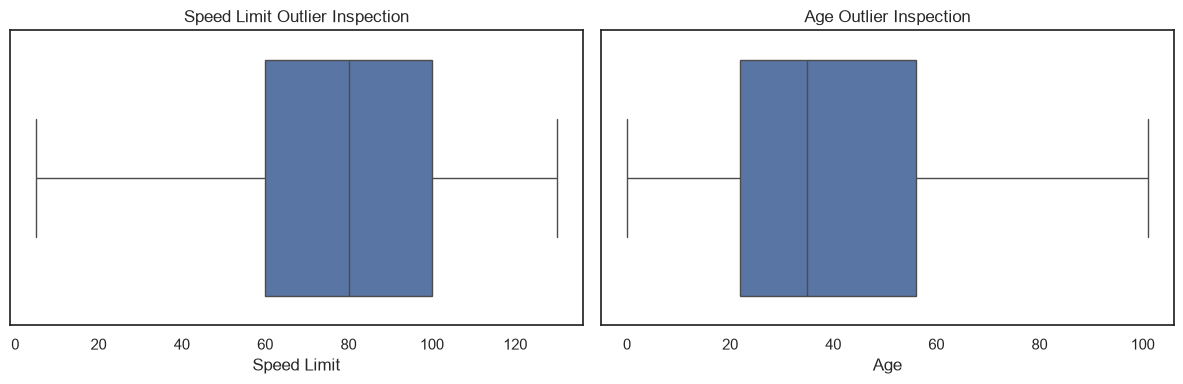

In [30]:
speed_col = [col for col in df.columns if "Speed" in col or "speed" in col]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if speed_col:
    col_name = speed_col[0]

    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")

    sns.boxplot(ax=axes[0], x=df[col_name]).set(
        title=f"{col_name} Outlier Inspection"
    )

    df.loc[(df[col_name] > 130) | (df[col_name] < 5), col_name] = np.nan
else:
    axes[0].set_title("Speed Limit Column Not Found")

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    sns.boxplot(ax=axes[1], x=df["Age"]).set(title="Age Outlier Inspection")

plt.tight_layout()
plt.show()

In [31]:

# 1. Split your date column into readable Year, Month, and Day columns
date_col = date_columns[0] if date_columns else None
if date_col and date_col in df.columns:
    df["Year"] = df[date_col].dt.year
    df["Month"] = df[date_col].dt.month
    df["DayOfWeek"] = df[date_col].dt.day_name()

# 2. SAVE IT: This saves your text columns normally without any True/False nonsense
df.to_csv("CrashDataSet_Cleaned.csv", index=False)

print(
    "Data cleansing complete. Cleaned dataset saved as 'CrashDataSet_Cleaned.csv'."
)




Data cleansing complete. Cleaned dataset saved as 'CrashDataSet_Cleaned.csv'.


In [ ]:
# Task 4 
# Irtiya Hana Nazirman

# 1. Summary of all numerical fields (Age, Speed Limit, Year, Month)
print("--- Numerical Data Summary ---")
print(df.describe())

# 2. Summary of all categorical/text fields (State, DayOfWeek)
print("\n--- Categorical Data Summary ---")
print(df.describe(include=["object"]))


--- Numerical Data Summary ---
          Crash ID    Month     Year  Speed Limit      Age  Unnamed: 23
count     55192.00 55192.00 55192.00     53715.00 55192.00         0.00
mean   20072036.36     6.58  2003.62        82.97    40.03          NaN
std     2447109.10     3.46    10.03        20.66    21.76          NaN
min    19891001.00     1.00  1989.00         5.00     0.00          NaN
25%    19952123.75     4.00  1995.00        60.00    22.00          NaN
50%    20031045.00     7.00  2003.00        80.00    35.00          NaN
75%    20121269.25    10.00  2012.00       100.00    56.00          NaN
max   201850059.00    12.00  2023.00       130.00   101.00          NaN

--- Categorical Data Summary ---
        State   Dayweek   Time Crash Type Bus Involvement  \
count   55192     55192  55144      55188           55145   
unique      8         7   1420          2               2   
top       NSW  Saturday  15:00     Single              No   
freq    16890     10063   1188      30639  

C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\3699528965.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=["object"]))


C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\2544823201.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


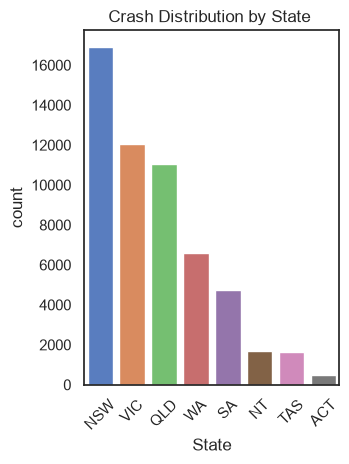

In [33]:


# Chart 2: Checking for Class Imbalance (Which States have the most crashes?)
plt.subplot(1, 2, 2)
if "State" in df.columns:
    sns.countplot(
        data=df,
        x="State",
        order=df["State"].value_counts().index,
        palette="muted",
    )
    plt.title("Crash Distribution by State ")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


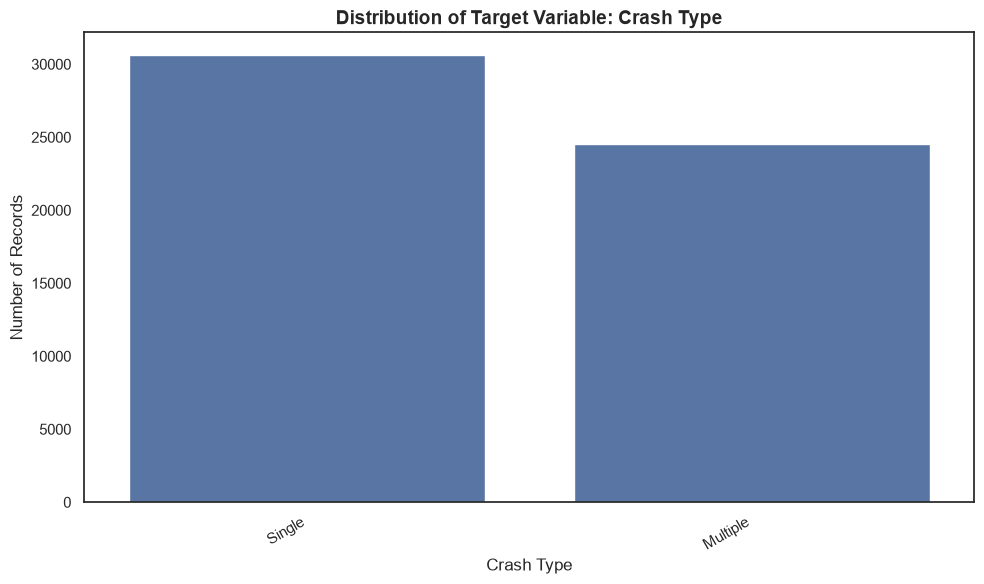

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clear any old error charts and set a clean size
plt.figure(figsize=(10, 6))

# 2. Use the exact column name from your dataset list
sns.countplot(data=df, x='Crash Type', order=df['Crash Type'].value_counts().index)

# 3. Rotate long labels slightly so they remain legible
plt.xticks(rotation=30, ha='right')

# 4. Polish up titles and visual boundaries
plt.title("Distribution of Target Variable: Crash Type", fontsize=14, fontweight='bold')
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()



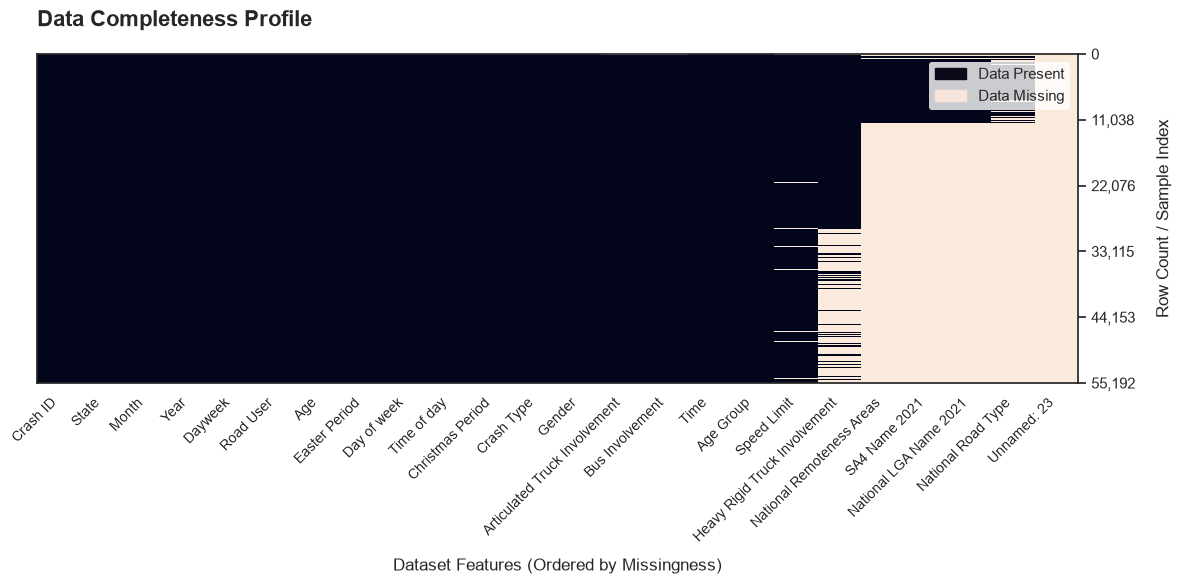

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

# 1. Sort columns by missingness
sorted_columns = df.isnull().mean().sort_values().index
df_sorted = df[sorted_columns]
total_rows = len(df_sorted)  # 55192

# 2. Set up the figure and main axes
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="white")

# 3. Plot the heatmap
sns.heatmap(df_sorted.isnull(), 
            cmap="rocket", 
            cbar=False, 
            yticklabels=False, 
            ax=ax1)

# 4. Create a second Y-axis on the right side with multiple scale ticks
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())  # Keep limits aligned with the heatmap
ax2.set_ylabel("Row Count / Sample Index", fontsize=12, labelpad=15)

# Generate 6 evenly spaced markers from 0 up to your max row count
tick_positions = np.linspace(0, total_rows, 6)

# Map the positions to the axis (Heatmaps flip the Y-axis, so we reverse the positions)
ax2.set_yticks(np.linspace(ax1.get_ylim()[0], ax1.get_ylim()[1], 6))
ax2.set_yticklabels([f"{int(val):,}" for val in reversed(tick_positions)])

# 5. Add the clean 2-color legend
present_patch = mpatches.Patch(color='#0b091a', label='Data Present')
missing_patch = mpatches.Patch(color='#f7e4db', label='Data Missing')
ax1.legend(handles=[present_patch, missing_patch], 
           loc='upper right', 
           frameon=True, 
           facecolor='white', 
           edgecolor='none', 
           fontsize=11)

# 6. Styling and labels
ax1.set_title("Data Completeness Profile", fontsize=16, fontweight='bold', pad=20, loc='left')
ax1.set_xlabel("Dataset Features (Ordered by Missingness)", fontsize=12, labelpad=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()


In [45]:
# 1. Create the target column (1 = 17-25, 0 = 26-101, 2 = Others)
df['Target_Age_Group'] = df['Age'].apply(lambda x: 1 if 17 <= x <= 25 else (0 if 26 <= x <= 101 else 2))

# 2. Verify the new distribution counts
print(df['Target_Age_Group'].value_counts())



Target_Age_Group
0    36850
1    14182
2     4160
Name: count, dtype: int64


C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\2750918893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target_Age_Group', palette='pastel')


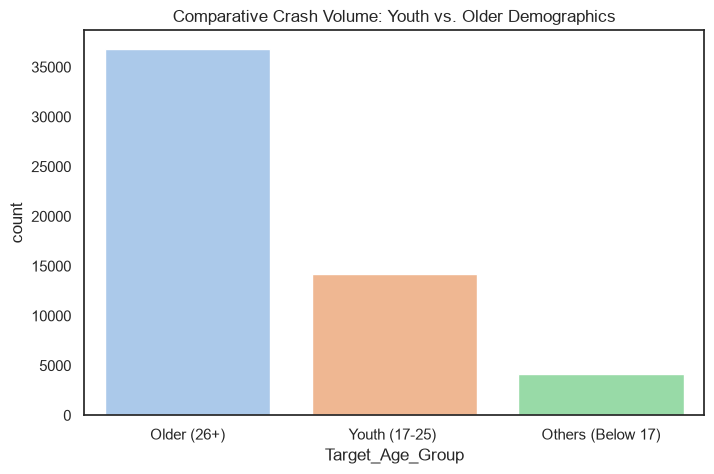

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target_Age_Group', palette='pastel')
plt.xticks([0, 1,2], ['Older (26+)', 'Youth (17-25) ', 'Others (Below 17)'])
plt.title("Comparative Crash Volume: Youth vs. Older Demographics")
plt.show()


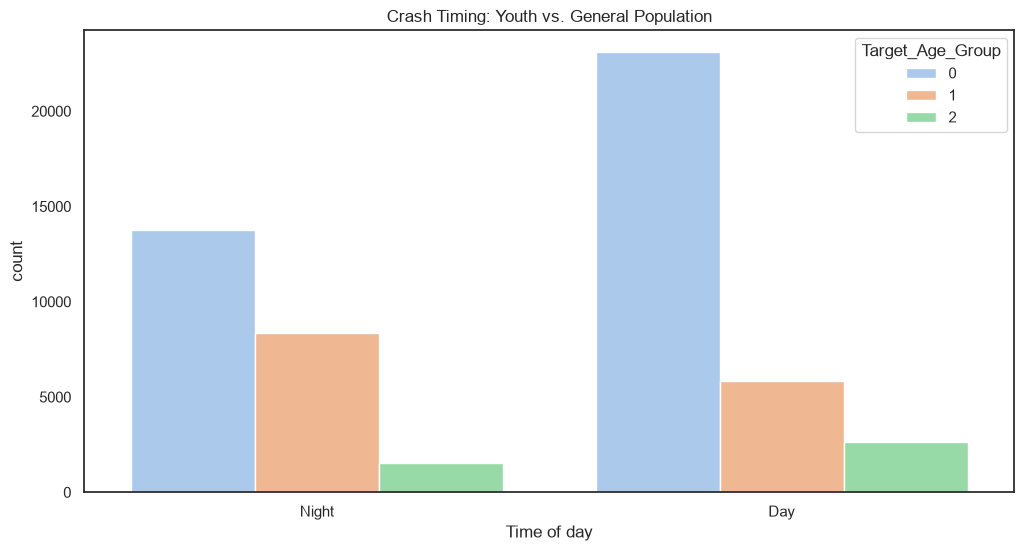

In [48]:
plt.figure(figsize=(12, 6))
# If 'Time of day' is categorical (e.g., 'Night', 'Day', 'Evening')
sns.countplot(data=df, x='Time of day', hue='Target_Age_Group', palette='pastel')
plt.title("Crash Timing: Youth vs. General Population")
plt.show()



C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\1568804029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


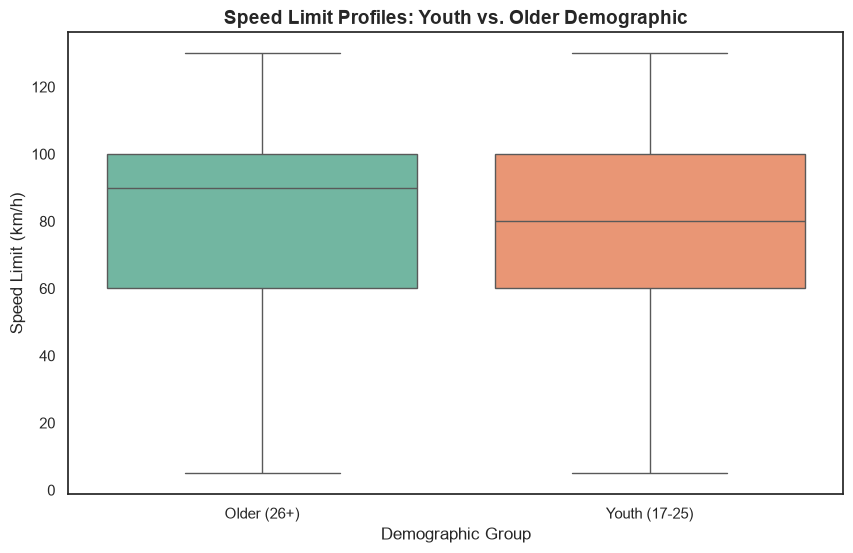

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Boxplot comparing the Speed Limit across ONLY group 0 and 1
sns.boxplot(
    data=df[df['Target_Age_Group'].isin([0, 1])], # Filtered out group 2 here
    x='Target_Age_Group', 
    y='Speed Limit', 
    palette='Set2'
)

# Make the labels clean and professional
plt.xticks([0, 1], ['Older (26+)', 'Youth (17-25)'])
plt.title("Speed Limit Profiles: Youth vs. Older Demographic", fontsize=14, fontweight='bold')
plt.xlabel("Demographic Group")
plt.ylabel("Speed Limit (km/h)")

plt.show()




In [40]:
print(f"Minimum Age: {df['Age'].min()} | Maximum Age: {df['Age'].max()}")


Minimum Age: 0.0 | Maximum Age: 101.0


In [41]:
# This prints the min, max, average (mean), and middle value (median)
print(df['Age'].describe()[['min', 'mean', '50%', 'max']])


min      0.00
mean    40.03
50%     35.00
max    101.00
Name: Age, dtype: float64


C:\Users\ASUS F15\AppData\Local\Temp\ipykernel_81544\2811404800.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


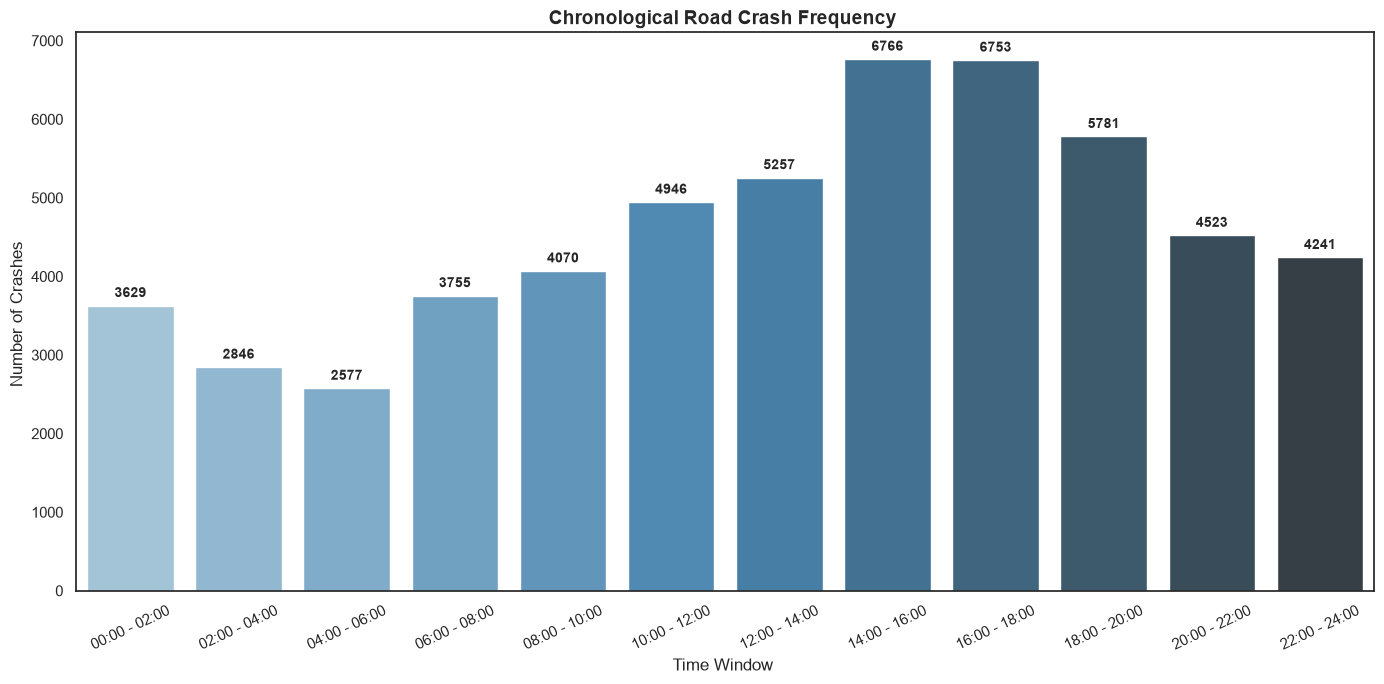

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Helper function to map time strings (e.g., "03:45") into a 2-hour block
def categorize_to_two_hours(time_str):
    try:
        clean_str = str(time_str).strip()
        hour = int(clean_str.split(':')[0])
        
        # Determine the 2-hour integer window bucket
        if 0 <= hour < 2: return "00:00 - 02:00"
        elif 2 <= hour < 4: return "02:00 - 04:00"
        elif 4 <= hour < 6: return "04:00 - 06:00"
        elif 6 <= hour < 8: return "06:00 - 08:00"
        elif 8 <= hour < 10: return "08:00 - 10:00"
        elif 10 <= hour < 12: return "10:00 - 12:00"
        elif 12 <= hour < 14: return "12:00 - 14:00"
        elif 14 <= hour < 16: return "14:00 - 16:00"
        elif 16 <= hour < 18: return "16:00 - 18:00"
        elif 18 <= hour < 20: return "18:00 - 20:00"
        elif 20 <= hour < 22: return "20:00 - 22:00"
        elif 22 <= hour <= 24: return "22:00 - 24:00"
    except:
        return "Unknown"

# 2. Create the new interval feature column
df['Two_Hour_Interval'] = df['Time'].apply(categorize_to_two_hours)

# Define the sequential time order from morning to night
time_sequence = [
    "00:00 - 02:00", "02:00 - 04:00", "04:00 - 06:00", "06:00 - 08:00",
    "08:00 - 10:00", "10:00 - 12:00", "12:00 - 14:00", "14:00 - 16:00",
    "16:00 - 18:00", "18:00 - 20:00", "20:00 - 22:00", "22:00 - 24:00"
]

# Filter data to exclude formatting errors or unknown values
plot_df = df[df['Two_Hour_Interval'].isin(time_sequence)]

# 3. Canvas setup (Make it wider so the text fits comfortably)
plt.figure(figsize=(14, 7))

# 4. Generate the countplot with forced chronological sequence order
ax = sns.countplot(
    data=plot_df, 
    x='Two_Hour_Interval', 
    order=time_sequence, 
    palette='Blues_d'  # Uses a gradient palette to denote density shifting
)

# 5. Place the exact number counts on top of each corresponding bar
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')

# 6. Formatting and Titles
plt.title("Chronological Road Crash Frequency ", fontsize=14, fontweight='bold')
plt.xlabel("Time Window ", fontsize=12)
plt.ylabel("Number of Crashes ", fontsize=12)

# Rotate labels slightly if they feel cramped
plt.xticks(rotation=25)
plt.tight_layout()

plt.show()






c:\Users\ASUS F15\Documents\data_ai_foundations\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\ASUS F15\Documents\data_ai_foundations\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\ASUS F15\Documents\data_ai_foundations\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\ASUS F15\Documents\data_ai_foundations\.venv\Lib\

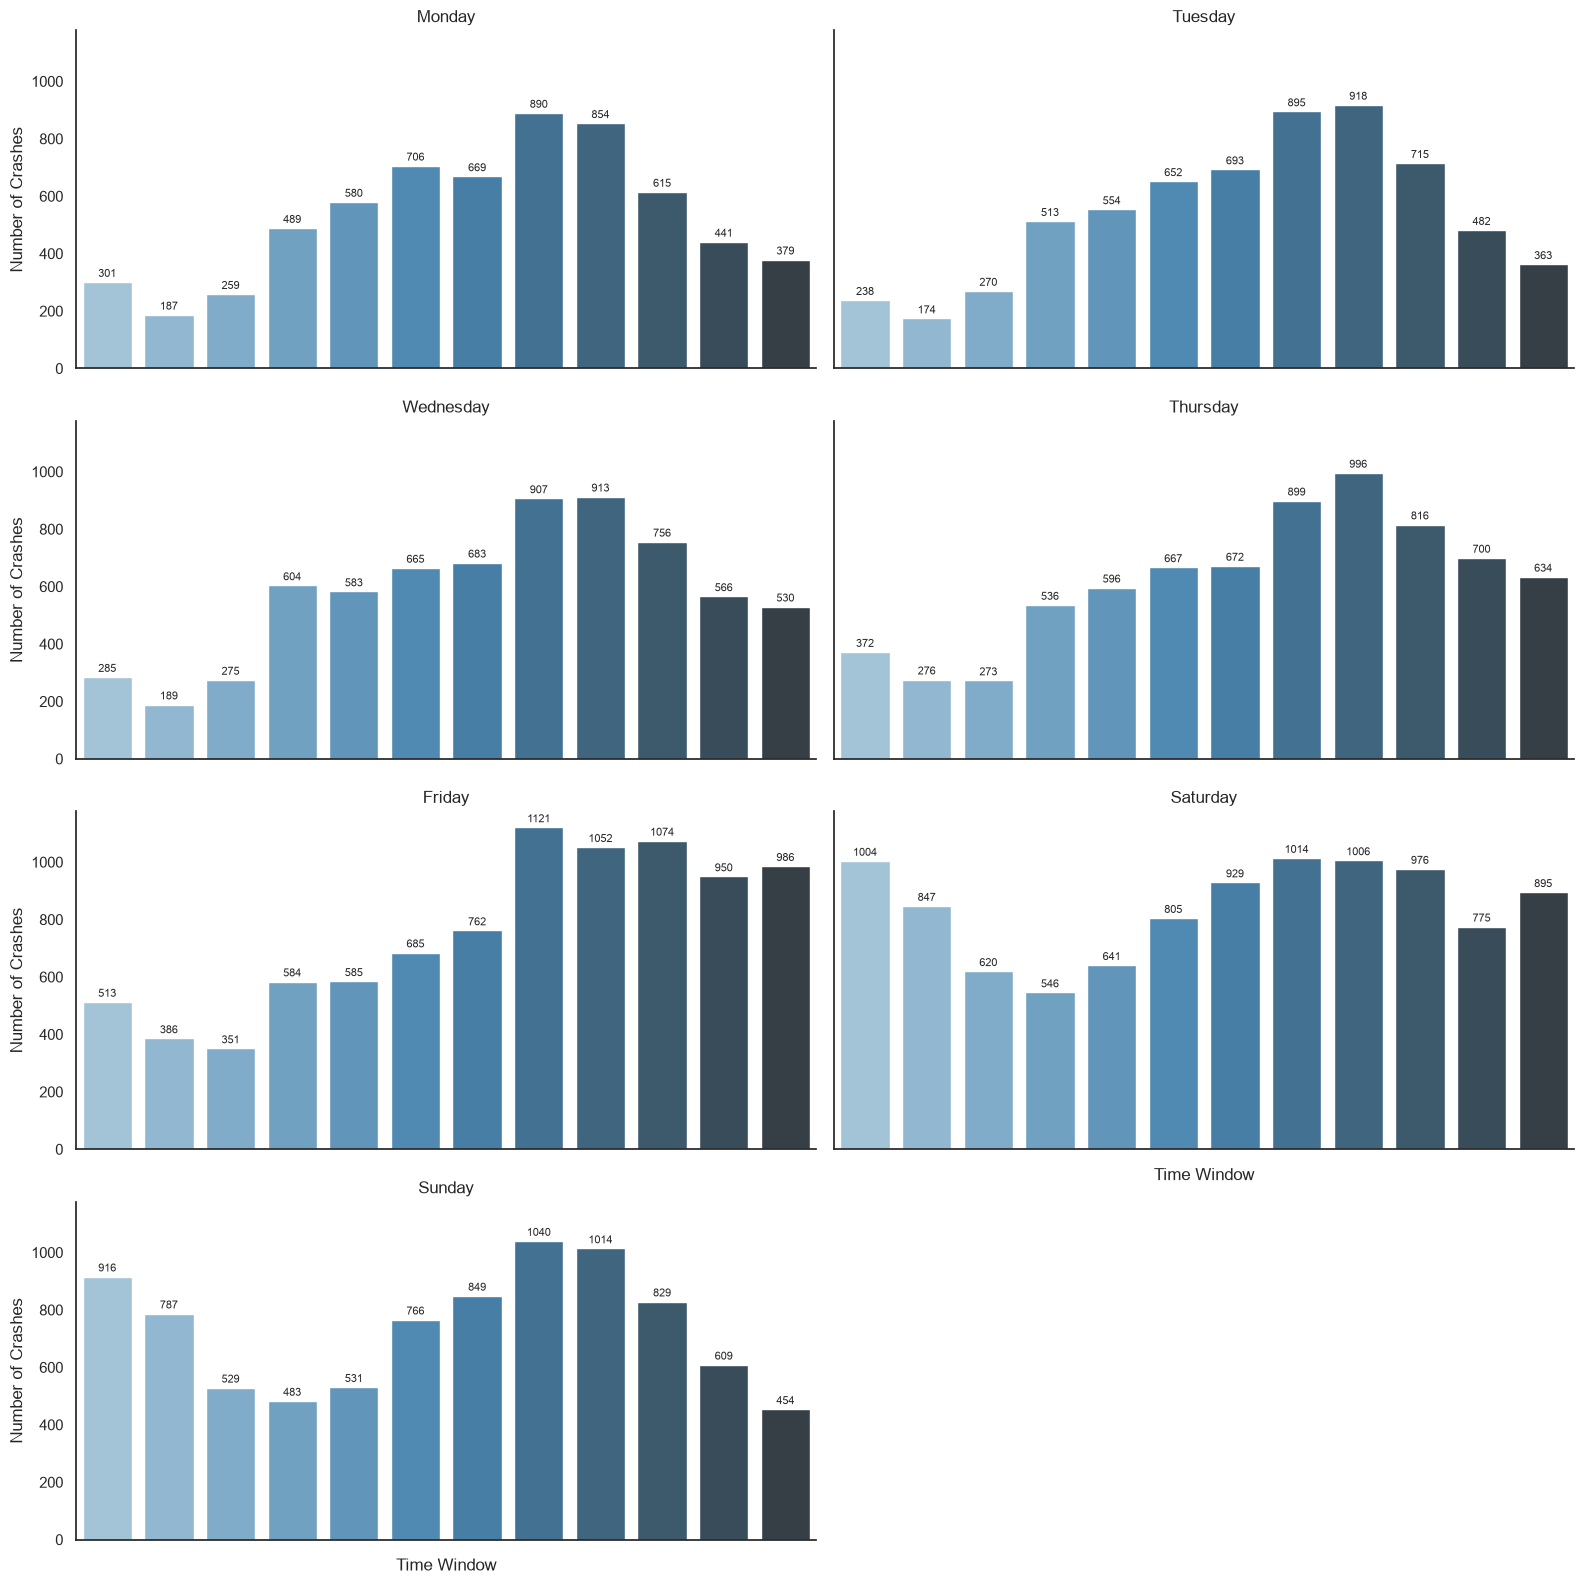

In [43]:
# Force the correct order for the day rows in the grid
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Initialize the layout grid
g = sns.FacetGrid(
    plot_df, 
    col="Dayweek", 
    col_order=day_order, 
    col_wrap=2, # Wrap after 2 charts to make a clean vertical layout
    height=4, 
    aspect=2,
    sharey=True # Keeps the Y-axis scale matching across all subplots
)

# 2. Map the countplot onto the grid layout
g.map_dataframe(
    sns.countplot, 
    x="Two_Hour_Interval", 
    order=time_sequence, 
    palette="Blues_d"
)

# --- 🛠️ THE FIX: FORCE TIMESTAMPS ON EVERY SUBPLOT ---
g.set(xticklabels=time_sequence)

# 3. Format and rotate the text labels on every single subplot axis
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    # Ensure the absolute counts print perfectly on top of the bars
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=8)

# 4. Clean up the surrounding padding titles
g.set_axis_labels("Time Window", "Number of Crashes")
g.set_titles(col_template="{col_name}")
plt.tight_layout()

plt.show()



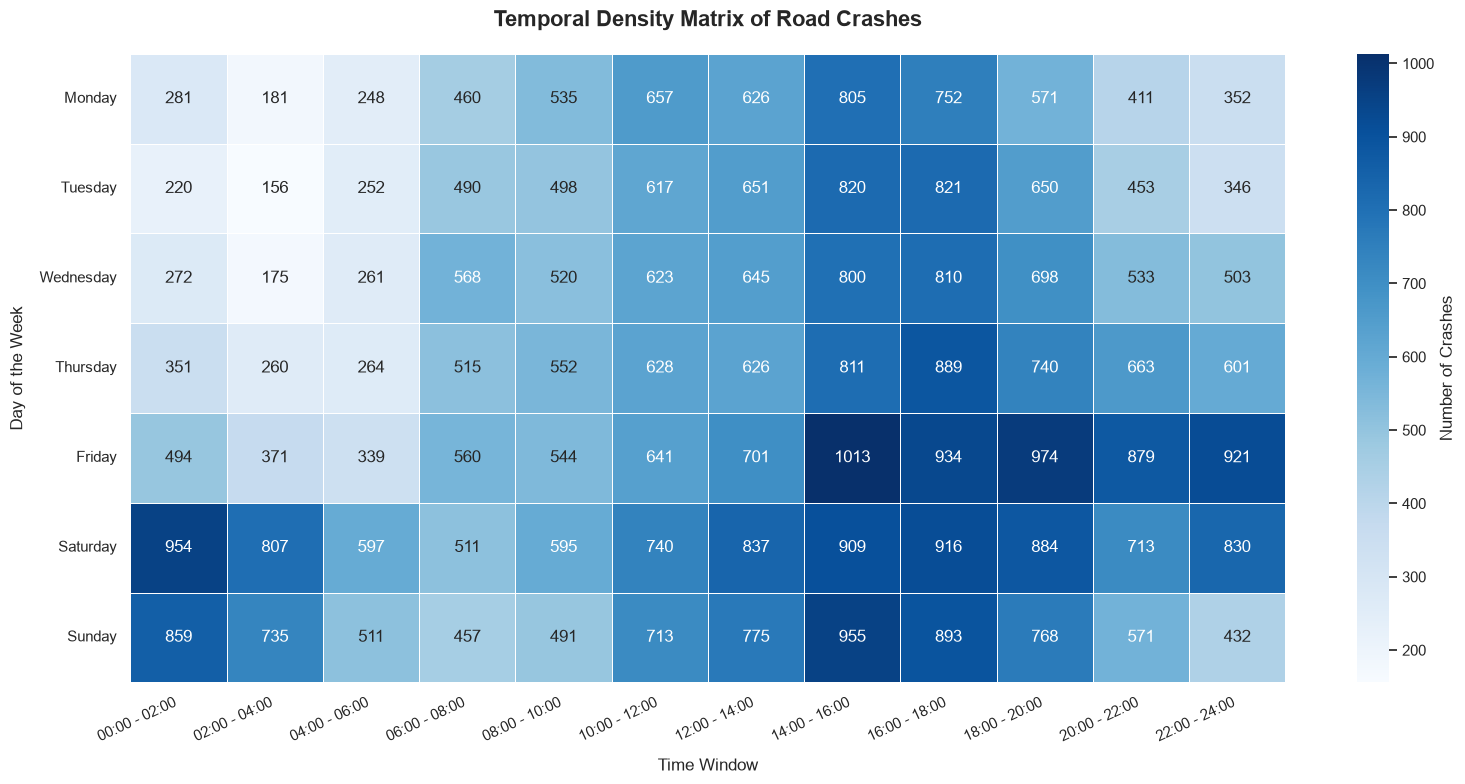

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure your 'Time' column is treated as a string, or convert if needed
# If you have a full Datetime column, you can extract the day name using: 
# df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()

# 1. Optimized vectorised approach for the 2-hour interval
def get_two_hour_interval(time_str):
    try:
        hour = int(str(time_str).split(':')[0].strip())
        if 0 <= hour <= 24:
            start_hour = (hour // 2) * 2
            return f"{start_hour:02d}:00 - {start_hour+2:02d}:00"
    except:
        return "Unknown"

df['Two_Hour_Interval'] = df['Time'].apply(get_two_hour_interval)

# 2. Define strict chronological sorting orders
time_sequence = [
    "00:00 - 02:00", "02:00 - 04:00", "04:00 - 06:00", "06:00 - 08:00",
    "08:00 - 10:00", "10:00 - 12:00", "12:00 - 14:00", "14:00 - 16:00",
    "16:00 - 18:00", "18:00 - 20:00", "20:00 - 22:00", "22:00 - 24:00"
]

day_sequence = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Filter data to exclude mapping errors
plot_df = df[
    df['Two_Hour_Interval'].isin(time_sequence) & 
    df['Dayweek'].isin(day_sequence) &
    df['Target_Age_Group'].isin([0, 1])  # Keep only youth and older demographics
].copy()

# 3. Pivot the data into a 2D matrix (Counts per Day vs Time Interval)
heatmap_data = (
    plot_df.groupby(['Dayweek', 'Two_Hour_Interval'])
    .size()
    .unstack(fill_value=0)
)

# Reindex both axes to enforce the chronological calendar view
heatmap_data = heatmap_data.reindex(index=day_sequence, columns=time_sequence)

# 4. Canvas setup for a heatmap matrix
plt.figure(figsize=(16, 8))

# 5. Generate the heatmap
ax = sns.heatmap(
    data=heatmap_data,
    cmap='Blues',       # Smooth color gradient denoting crash density
    annot=True,         # Places the exact crash numbers in the squares
    fmt='d',            # Formats annotations as regular integers
    linewidths=0.5,     # Adds clean gridlines between boxes
    cbar_kws={'label': 'Number of Crashes'}
)

# 6. Formatting, Titles, and Labels
plt.title("Temporal Density Matrix of Road Crashes", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Time Window", fontsize=12, labelpad=10)
plt.ylabel("Day of the Week", fontsize=12, labelpad=10)

# Rotate labels so they don't overlap
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
